# Editor de histograma interativo

Carrega uma imagem em tons de cinza, plota o histograma, implementa equalização de histograma do zero e compara com `cv2.equalizeHist`.

(512, 512) uint8


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

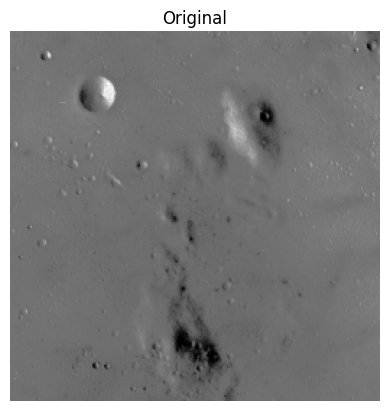

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.moon()  # já em tons de cinza, uint8, baixo contraste
print(img.shape, img.dtype)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

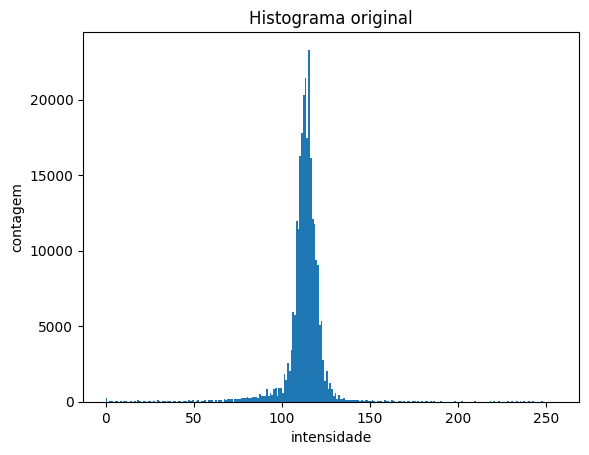

In [2]:
def plot_hist(img, title):
    plt.hist(img.ravel(), bins=256, range=(0, 256))
    plt.title(title)
    plt.xlabel("intensidade")
    plt.ylabel("contagem")

plot_hist(img, "Histograma original")

In [3]:
def equalize_from_scratch(img):
    """Equalização de histograma manual, seguindo o mesmo critério do cv2.equalizeHist:
    h(v) = round((cdf(v) - cdf_min) / (total - cdf_min) * 255)
    """
    hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0][0]
    total = img.size

    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255).clip(0, 255).astype(np.uint8)
    return lut[img]

img_eq_manual = equalize_from_scratch(img)
img_eq_cv2 = cv2.equalizeHist(img)

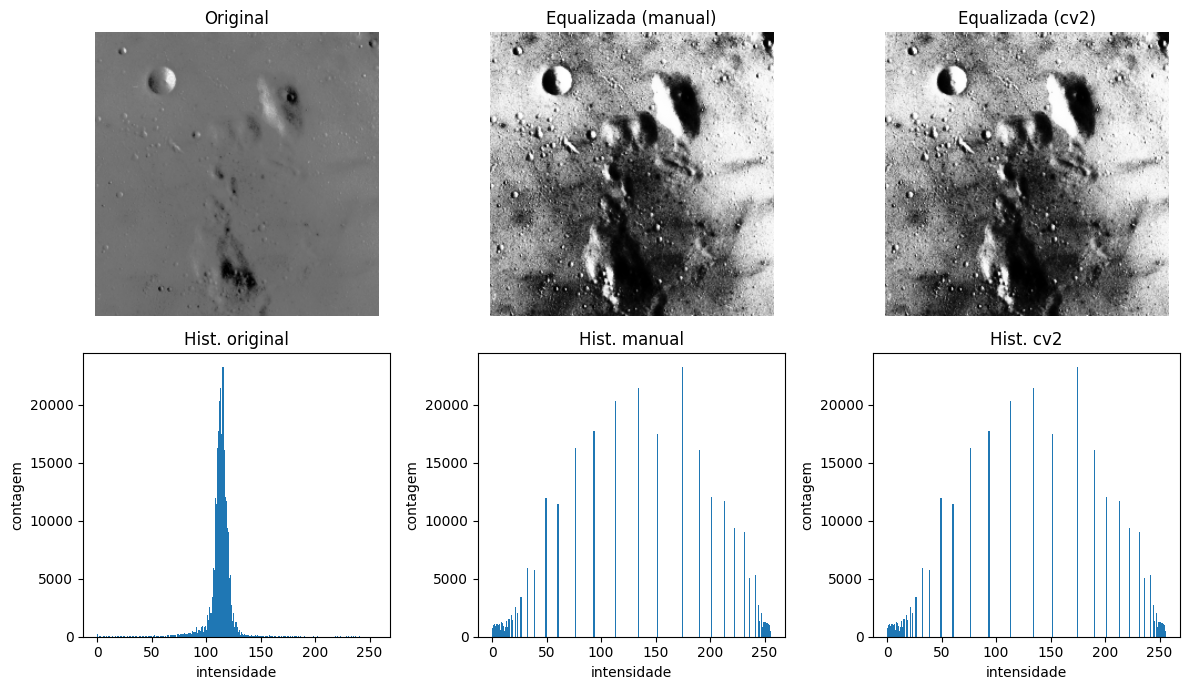

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

axes[0, 0].imshow(img, cmap="gray"); axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
axes[0, 1].imshow(img_eq_manual, cmap="gray"); axes[0, 1].set_title("Equalizada (manual)"); axes[0, 1].axis("off")
axes[0, 2].imshow(img_eq_cv2, cmap="gray"); axes[0, 2].set_title("Equalizada (cv2)"); axes[0, 2].axis("off")

plt.sca(axes[1, 0]); plot_hist(img, "Hist. original")
plt.sca(axes[1, 1]); plot_hist(img_eq_manual, "Hist. manual")
plt.sca(axes[1, 2]); plot_hist(img_eq_cv2, "Hist. cv2")

plt.tight_layout()

In [5]:
# self-check: implementação manual deve bater com cv2 (mesma fórmula de LUT)
diff = np.abs(img_eq_manual.astype(int) - img_eq_cv2.astype(int))
assert diff.max() <= 1, f"diferença máxima entre manual e cv2: {diff.max()}"
print("OK: equalização manual bate com cv2.equalizeHist (diferença máxima:", diff.max(), ")")

OK: equalização manual bate com cv2.equalizeHist (diferença máxima: 0 )
